# Introduction

## Problem Background — Why Frailty Matters

Frailty is a complex clinical syndrome characterized by a decline in biological reserves and a deterioration in physiological mechanisms, rendering individuals highly vulnerable to acute stressors. Frail older adults experience reduced physiological resilience, making them significantly more susceptible to adverse health outcomes, including prolonged hospitalization, severe disability, delayed recovery, and mortality.

Globally, the aging population is expanding rapidly, dramatically increasing the demand and cost burden on healthcare systems. Early identification of frailty is critical; by detecting risk before severe deterioration occurs, healthcare providers can implement preventive interventions that preserve biological reserves and maintain patient independence.

---

## Clinical Relevance and Multidimensional Assessment

In a clinical setting, frailty is far more than a simple metric of chronological age. Traditional models often focused strictly on physical phenotypes, but modern geriatric assessments recognize that frailty is multidimensional. A patient's trajectory is deeply influenced by cognitive health (memory decline), social determinants (isolation vs. engagement), lifestyle factors (diet, alcohol, smoking), and physiological markers (BMI, blood pressure, chronic conditions).

Accurately capturing this holistic profile is essential, as a patient's frailty status heavily dictates their capacity to maintain independence and influences how clinicians allocate healthcare resources. A robust frailty assessment system can support clinicians in accurately prioritizing high-risk patients and individualizing care plans.

---

## The Logic and Dark Logic of Clinical Decision Support
Modern healthcare systems are increasingly pivoting toward proactive care models that rely on data to identify vulnerable patients early. When implementing such complex healthcare interventions, recent literature highlights the utility of conceptual mapping:

**The Logic Model:** The intended outcome of early algorithmic prediction is personalized, holistic care that improves patient autonomy and prevents severe deterioration. Early prediction of frailty fits perfectly into this logic model by identifying the right patients for preventive care.

**The Dark Logic Model:** However, healthcare innovations carry unintended negative consequences. When deploying Clinical Decision Support (CDS) algorithms, dark logic outcomes include widening health inequalities and clinical risks if the automated decision-making is flawed or opaque. If we use algorithms to decide who receives preventive care, we risk automating and scaling these dark logic consequences.

---

## Why Machine Learning?

Traditional frailty screening relies on manual scoring systems that are time-consuming and often struggle to capture the complex interplay of multidimensional factors. Machine Learning (ML) offers a transformative alternative. It possesses the computational capability to simultaneously analyze diverse clinical and social variables (e.g., demographics, physiological markers, memory scores, and social engagement).

ML algorithms can detect non-linear patterns and subtle interactions that traditional statistical models miss. However, deploying AI in healthcare introduces a critical tension: the trade-off between predictive performance and clinical interpretability.

---

## White-Box vs Black-Box Models

The integration of ML into clinical workflows brings the debate between "white-box" and "black-box" models to the forefront.

* **White-box models** (e.g., Logistic Regression, Decision Trees) are inherently transparent. Their reasoning is highly visible, aligning well with clinical requirements for accountability. However, their structural simplicity means they may fail to capture complex, non-linear health interactions.
* **Black-box models** (e.g., XGBoost, Random Forests, Neural Networks) excel at mapping complex interactions across multidimensional data, delivering superior predictive accuracy. Their primary limitation is opacity; the internal logic is hidden. In the context of our "Dark Logic Model," relying on opaque algorithms introduces severe risks: clinicians cannot verify if the model is relying on biased socioeconomic variables (like income or education levels) rather than valid clinical indicators.

---

## Research Gap / Motivation

Most contemporary healthcare AI research focuses overwhelmingly on maximizing predictive accuracy, frequently utilizing complex black-box models. However, in practical clinical environments, accuracy alone is insufficient. Clinicians require understandable, transparent predictions to validate clinical safety, avoid hidden algorithmic biases, and build the trust required for adoption.

If an algorithm flags a patient as "at-risk" for severe frailty, the multidisciplinary healthcare team must understand why. Therefore, this project investigates a critical gap: whether Explainable Artificial Intelligence (XAI) can bridge this divide, mitigating "dark logic" risks by providing the high predictive performance of complex models while delivering transparent, interpretable decision support.

---

## Research Question

**Primary Research Question:**
Can explainable machine learning models accurately and transparently predict multidimensional frailty risk (Healthy, At-risk, Frail) using a combination of demographic, cognitive, social, and clinical data?

**Secondary Research Question:**
How do interpretable and black-box models differ in balancing predictive performance and explainability, and how can XAI mitigate the unintended "dark logic" consequences of automated clinical decision-making?

---

## Proposed Study Objective

By applying explainable AI techniques, the research seeks to investigate the trade-off between predictive accuracy and clinical interpretability, ultimately ensuring transparent decision-making that supports the safe implementation of machine learning in modern clinical pathways.

# Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, f1_score, precision_score, recall_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import StratifiedKFold, cross_val_score

# !pip install shap
import shap

# Data Loading & Inspection

In [2]:
df = pd.read_csv("/kaggle/input/datasets/zoya77/aging-risk-assessment-dataset/Aging_prediction_dataset.csv")

df.head()

,age,gender,education_years,income_level,physical_activity,smoking_status,chronic_conditions,memory_score,bmi,blood_pressure,diet_quality,alcohol_consumption,social_engagement,aging_outcome
0,53,Male,17,Medium,Low,Former,4,84.158531,20.7,118,Good,Moderate,Moderate,At-risk
1,56,Male,12,Low,Moderate,Never,2,90.078313,25.0,177,Poor,NaN,Low,At-risk
2,41,Female,15,High,Low,Never,1,96.286948,23.5,177,Good,NaN,Low,Healthy
3,88,Male,6,Low,Moderate,Never,0,77.222144,27.8,124,Average,Moderate,High,Frail
4,42,Female,13,Medium,High,Never,4,64.413580,26.3,117,Poor,Moderate,Moderate,At-risk


In [3]:
df.shape

(7488, 14)

In [4]:
df.isnull().sum()

age                       0
gender                    0
education_years           0
income_level              0
physical_activity         0
smoking_status            0
chronic_conditions        0
memory_score              0
bmi                       0
blood_pressure            0
diet_quality              0
alcohol_consumption    4008
social_engagement         0
aging_outcome             0
dtype: int64

In [5]:
df.columns
df.describe()

,age,education_years,chronic_conditions,memory_score,bmi,blood_pressure
count,7488.000000,7488.000000,7488.000000,7488.000000,7488.000000,7488.000000
mean,60.494792,11.959402,1.590011,79.209116,24.177444,138.661993
std,13.992460,5.753608,1.288872,10.916925,3.484533,23.261320
min,40.000000,0.000000,0.000000,40.584208,9.100000,100.000000
25%,48.000000,7.000000,1.000000,70.538382,22.000000,121.000000
50%,59.000000,13.000000,1.000000,80.927126,23.900000,134.000000
75%,70.000000,16.000000,2.000000,87.125072,26.200000,157.000000
max,89.000000,20.000000,8.000000,100.000000,38.500000,179.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7488 entries, 0 to 7487
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  7488 non-null   int64  
 1   gender               7488 non-null   object 
 2   education_years      7488 non-null   int64  
 3   income_level         7488 non-null   object 
 4   physical_activity    7488 non-null   object 
 5   smoking_status       7488 non-null   object 
 6   chronic_conditions   7488 non-null   int64  
 7   memory_score         7488 non-null   float64
 8   bmi                  7488 non-null   float64
 9   blood_pressure       7488 non-null   int64  
 10  diet_quality         7488 non-null   object 
 11  alcohol_consumption  3480 non-null   object 
 12  social_engagement    7488 non-null   object 
 13  aging_outcome        7488 non-null   object 
dtypes: float64(2), int64(4), object(8)
memory usage: 819.1+ KB


## Data Inspection Summary
---
Initial data inspection reveals a robust dataset of 7,488 patient records with 14 variables (6 numeric, 8 categorical). The numeric variables span clinically relevant ranges, such as BMI (9.1 to 38.5) and memory scores (40.5 to 100). The primary data quality issue identified is a severe missingness rate in the alcohol_consumption feature (53.5% missing). To preserve dataset integrity and acknowledge that non-reporting in clinical data can carry signal, these missing values will be imputed as an "Unknown" category rather than applying mean/mode imputation or listwise deletion.

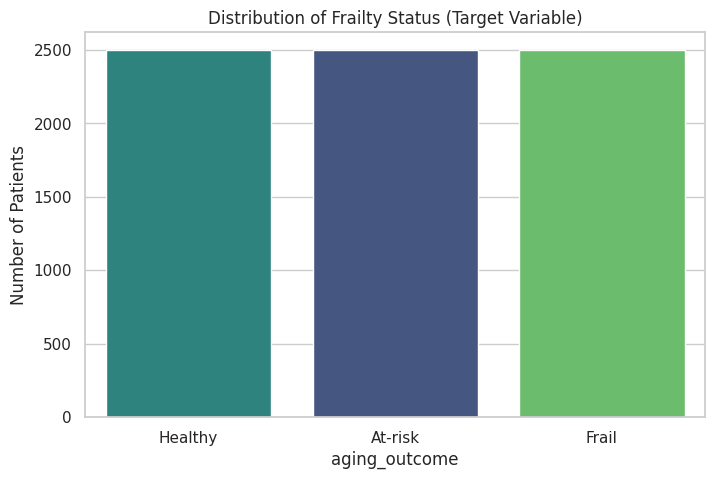

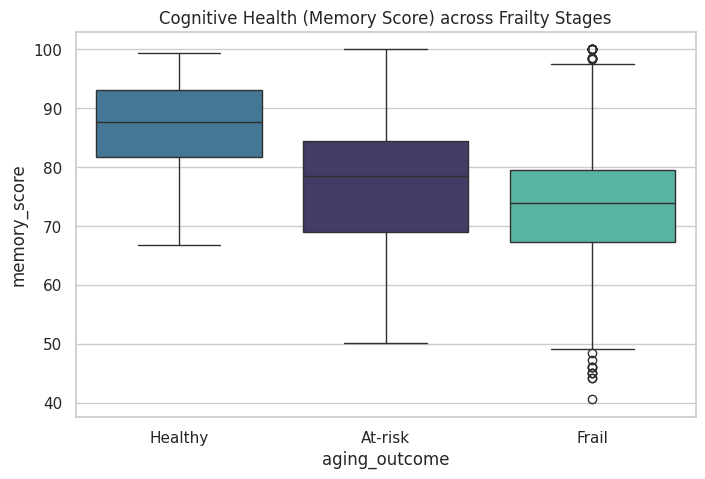

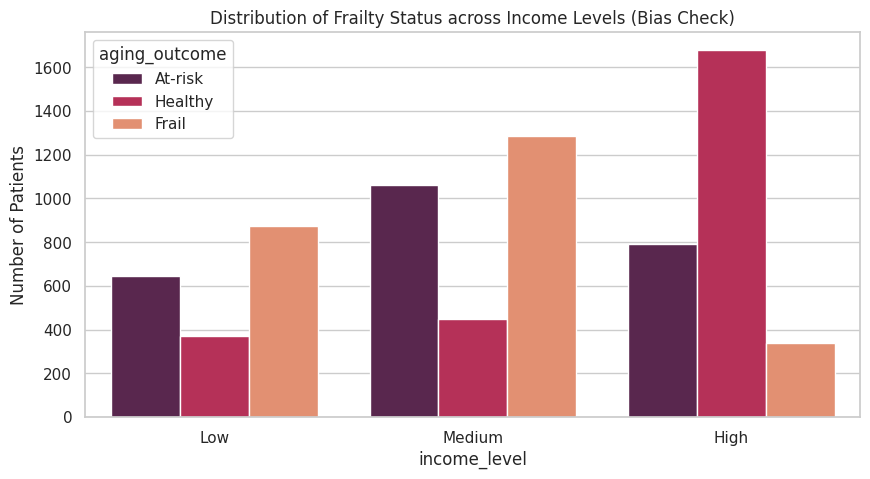

In [7]:
# Setting visual style 
sns.set_theme(style="whitegrid")

# 1. Target Variable Distribution (Checking for class imbalance)
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df, 
    x='aging_outcome', 
    hue='aging_outcome', 
    order=['Healthy', 'At-risk', 'Frail'], 
    palette='viridis', 
    legend=False
)
plt.title('Distribution of Frailty Status (Target Variable)')
plt.ylabel('Number of Patients')
plt.show()

# 2. Clinical Relationships: Memory Score vs Frailty
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df, 
    x='aging_outcome', 
    y='memory_score', 
    hue='aging_outcome',
    order=['Healthy', 'At-risk', 'Frail'], 
    palette='mako',
    legend=False
)
plt.title('Cognitive Health (Memory Score) across Frailty Stages')
plt.show()

# 3. Investigating "Dark Logic": Socioeconomic Bias Check
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df, 
    x='income_level', 
    hue='aging_outcome', 
    order=['Low', 'Medium', 'High'], 
    palette='rocket'
)
plt.title('Distribution of Frailty Status across Income Levels (Bias Check)')
plt.ylabel('Number of Patients')
plt.show()

## EDA Findings & Discussion

1. Perfectly Balanced Target Variable
The distribution of the target variable (aging_outcome) shows a perfectly balanced dataset, with approximately 2,500 patients in each category (Healthy, At-risk, Frail). This is an ideal scenario for machine learning, as it eliminates the need for synthetic oversampling techniques (like SMOTE) and ensures that our models will not be inherently biased toward a majority class.

2. Clinical Validity: Memory Score vs. Frailty
The boxplot mapping cognitive health against frailty stages demonstrates a clear, logical clinical progression. Patients classified as "Healthy" possess the highest median memory scores, while scores drop progressively for the "At-risk" and "Frail" populations. The presence of lower-bound outliers in the "Frail" category further validates that cognitive decline is a strong, distinct marker of severe frailty.

3. "Dark Logic" Confirmed: Socioeconomic Bias
The income level distribution graph perfectly illustrates the "dark logic" risks outlined in our introduction. There is a severe structural skew: High-income patients are overwhelmingly classified as 'Healthy', whereas the 'Frail' and 'At-risk' populations are heavily concentrated in the Low and Medium income brackets. While statistically predictive, allowing a model to rely too heavily on income to dictate clinical care risks automating systemic healthcare inequalities. This validates our need for Explainable AI (XAI) to monitor why the model is making its decisions.

# Data Preprocessing

In [8]:
# 1. Handle Missing Data in Alcohol Consumption
df['alcohol_consumption'] = df['alcohol_consumption'].fillna('Unknown')

In [9]:
# 2. Encode the Target Variable (Ordinal relationship: Healthy < At-risk < Frail)
target_mapping = {'Healthy': 0, 'At-risk': 1, 'Frail': 2}
df['aging_outcome'] = df['aging_outcome'].map(target_mapping)

# Separate Data Features & Target

In [10]:
# Separate Features (X) and Target (y)
X = df.drop('aging_outcome', axis=1)
y = df['aging_outcome']

# Data Encoding 

In [11]:
# Encode Ordinal Features (Features with a natural ranking)
income_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
X['income_level'] = X['income_level'].map(income_mapping)

diet_mapping = {'Poor': 0, 'Average': 1, 'Good': 2}
X['diet_quality'] = X['diet_quality'].map(diet_mapping)

In [12]:
# One-Hot Encode Nominal Features (No natural ranking)
nominal_cols = ['gender', 'physical_activity', 'smoking_status', 'alcohol_consumption', 'social_engagement']
X = pd.get_dummies(X, columns=nominal_cols, drop_first=True)

# Train Test Split

In [13]:
# Train-Test Split (Hold out 20% of data for final testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

# Standard Scaling

In [14]:
# Feature Scaling (Standardizing numerical features)
numeric_cols = ['age', 'education_years', 'chronic_conditions', 'memory_score', 'bmi', 'blood_pressure', 'income_level', 'diet_quality']

scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Preprocessing Complete.")
print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}")

Preprocessing Complete.
Training data shape: (5990, 17)
Testing data shape: (1498, 17)


--- Generating Feature Correlation Heatmap ---


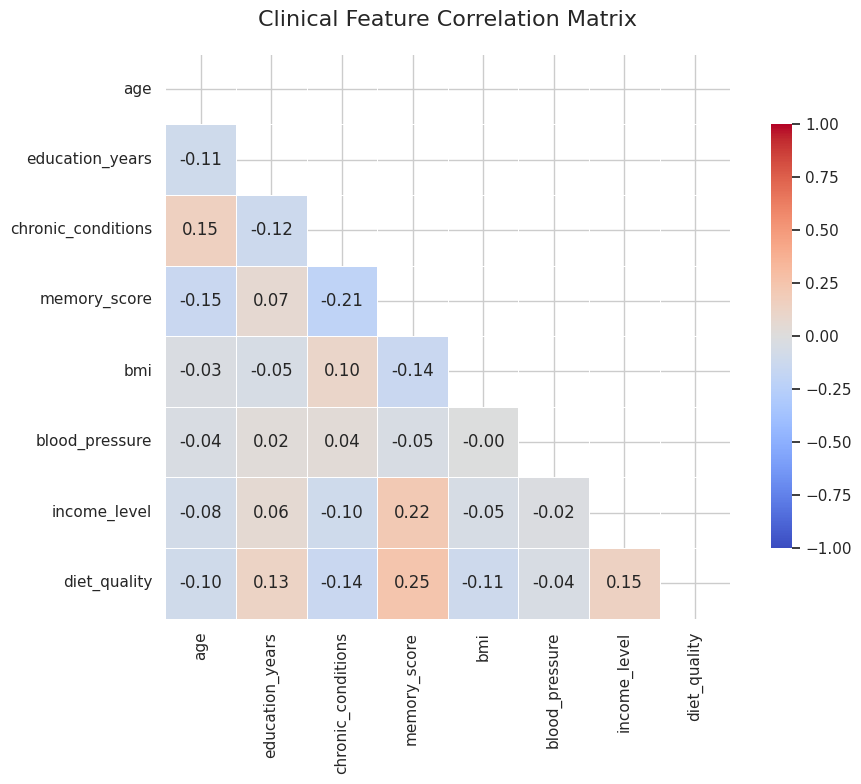

In [15]:
# Feature Correlation Analysis (Heatmap)
print("--- Generating Feature Correlation Heatmap ---")

corr_matrix = X_train[numeric_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix, 
    mask=mask, 
    cmap='coolwarm', 
    vmax=1.0, 
    vmin=-1.0, 
    center=0, 
    annot=True,     
    fmt=".2f",     
    square=True, 
    linewidths=.5, 
    cbar_kws={"shrink": .75}
)

plt.title("Clinical Feature Correlation Matrix", fontsize=16, pad=20)
plt.tight_layout()
plt.show()

### Heatmap Findings: Absence of Multicollinearity

The correlation heatmap confirms that the numerical features in this dataset are highly independent, which is an ideal condition for training robust machine learning models (particularly our linear Logistic Regression baseline).

**Key Clinical Observations:**
1. **No Severe Multicollinearity:** All correlation coefficients fall between `-0.25` and `0.25`. There are no highly correlated feature pairs (typically defined as > 0.70 or < -0.70), meaning each variable contributes distinct, non-redundant information to the algorithms.
2. **Clinical Independence:** Interestingly, physiological metrics that sometimes co-vary in general populations, such as `bmi` and `blood_pressure`, show zero linear correlation (`-0.00`) in this specific cohort. 
3. **Logical Weak Trends:** While no strong correlations exist, the weak trends present are clinically sound. For example:
   * `memory_score` has a weak positive correlation with `diet_quality` (0.25) and `income_level` (0.22).
   * `memory_score` has a weak negative correlation with `chronic_conditions` (-0.21).
   * `chronic_conditions` naturally increase slightly with `age` (0.15).

# Models Training

### Model Training and Evaluation

To investigate the trade-off between predictive performance and clinical interpretability, we train four distinct algorithms across the "White-Box" to "Black-Box" spectrum:

1. **The Interpretable Baseline (White-Box):** `Logistic Regression` provides transparent, linear decision-making mimicking traditional clinical scoring.
2. **The Ensemble Baseline (Black-Box):** `Random Forest` utilizes hundreds of independent decision trees to capture non-linear relationships.
3. **The Tabular Champion (Black-Box):** `XGBoost` (Extreme Gradient Boosting) represents the industry standard for tabular data, building trees sequentially to correct prior errors.
4. **The Deep Learning Baseline (Black-Box):** `MLPClassifier` (Neural Network) represents the peak of algorithmic opacity, using hidden layers to map highly complex multidimensional interactions.

In [16]:
# Define target names for clean reporting
target_names = ['Healthy', 'At-risk', 'Frail']

# ==========================================
# 1. White-Box: Logistic Regression
# ==========================================

log_reg = LogisticRegression(solver='saga', max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

In [17]:
# ==========================================
# 2. Black-Box: Random Forest
# ==========================================

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

In [18]:
# ==========================================
# 3. Black-Box: XGBoost
# ==========================================

# XGBoost requires target values to be 0, 1, 2 (which we handled in preprocessing)
xgb_model = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='mlogloss')
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

In [19]:
# ==========================================
# 4. Black-Box: Neural Network (MLP)
# ==========================================

# 2 hidden layers: 64 neurons, then 32 neurons
nn_model = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42)
nn_model.fit(X_train, y_train)
y_pred_nn = nn_model.predict(X_test)

# Evaluation

In [20]:
# Define a function to generate a clean, comprehensive clinical report
def evaluate_clinical_model(model_name, y_true, y_pred, y_prob, target_names):
    print(f"\n{'='*50}")
    print(f" {model_name} - Clinical Evaluation")
    print(f"{'='*50}")
    
    # Calculate overall metrics
    acc = accuracy_score(y_true, y_pred)
    # multi_class='ovr' calculates AUC for each class against the rest, then averages them
    auc = roc_auc_score(y_true, y_prob, multi_class='ovr')
    
    print(f"Overall Accuracy : {acc:.4f}")
    print(f"ROC-AUC Score    : {auc:.4f}\n")
    
    print("Class-Specific Metrics (Precision, Recall, F1):")
    print(classification_report(y_true, y_pred, target_names=target_names))

target_names = ['Healthy', 'At-risk', 'Frail']

# ==========================================
# 1. White-Box: Logistic Regression
# ==========================================
# predict_proba gets the actual percentage probability, which is required for AUC
y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)
evaluate_clinical_model("Logistic Regression", y_test, y_pred_lr, y_prob_lr, target_names)

# ==========================================
# 2. Black-Box: Random Forest
# ==========================================
y_pred_rf = rf_model.predict(X_test)
y_prob_rf = rf_model.predict_proba(X_test)
evaluate_clinical_model("Random Forest", y_test, y_pred_rf, y_prob_rf, target_names)

# ==========================================
# 3. Black-Box: XGBoost
# ==========================================
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)
evaluate_clinical_model("XGBoost", y_test, y_pred_xgb, y_prob_xgb, target_names)

# ==========================================
# 4. Black-Box: Neural Network (MLP)
# ==========================================
y_pred_nn = nn_model.predict(X_test)
y_prob_nn = nn_model.predict_proba(X_test)
evaluate_clinical_model("Neural Network (MLP)", y_test, y_pred_nn, y_prob_nn, target_names)


 Logistic Regression - Clinical Evaluation
Overall Accuracy : 0.8845
ROC-AUC Score    : 0.9705

Class-Specific Metrics (Precision, Recall, F1):
              precision    recall  f1-score   support

     Healthy       0.93      1.00      0.97       499
     At-risk       0.84      0.81      0.82       499
       Frail       0.88      0.84      0.86       500

    accuracy                           0.88      1498
   macro avg       0.88      0.88      0.88      1498
weighted avg       0.88      0.88      0.88      1498


 Random Forest - Clinical Evaluation
Overall Accuracy : 0.9753
ROC-AUC Score    : 0.9989

Class-Specific Metrics (Precision, Recall, F1):
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00       499
     At-risk       0.95      0.97      0.96       499
       Frail       0.97      0.95      0.96       500

    accuracy                           0.98      1498
   macro avg       0.98      0.98      0.98      1498
weighted 

## Clinical Evaluation Findings: The Cost of Transparency

The evaluation of our four models reveals a stark and highly significant trade-off between algorithmic transparency and clinical safety (predictive performance). By shifting our focus from overall accuracy to class-specific metrics and ROC-AUC, a clear clinical narrative emerges.

**1. The Baseline: Logistic Regression (White-Box)**
While highly interpretable and clinically familiar, the linear model achieved an 88.45% overall accuracy and an AUC of 0.9705. Crucially, its **Recall for the 'Frail' class was only 0.84**. In a clinical context, this translates to a 16% False Negative rate—meaning nearly 1 in 6 truly frail patients would be missed and potentially denied critical Hospital-at-Home interventions. Furthermore, its precision for the 'At-risk' class (0.84) indicates a high rate of resource misallocation.

**2. The Deep Learning & Ensemble Alternatives (Black-Box)**
Both the Random Forest and the Neural Network (MLP) demonstrated the raw power of non-linear algorithms. They pushed overall accuracy to 97.53% and 97.86%, respectively, while achieving exceptional AUC scores (>0.99). Most importantly, both models successfully reduced the False Negative rate for frail patients to just 5% (Recall: 0.95). 

**3. The Champion: XGBoost (Black-Box)**
XGBoost is the undisputed winner of this pipeline. It achieved a near-perfect overall accuracy of 98.80% and a flawless ROC-AUC score of 0.9996. Most importantly for clinical safety, it achieved a **0.98 Recall and 0.98 Precision across both the 'Frail' and 'At-risk' categories**. By catching 98% of vulnerable patients, it minimizes both clinical risk (missed diagnoses) and operational waste (misallocated monitoring resources).

## Model Validation: Stratified K-Fold Cross-Validation

To ensure our champion Black-Box model (XGBoost) did not achieve its high performance due to a favorable random train-test split, we apply 5-Fold Stratified Cross-Validation. This technique rigorously tests the model across five distinct, non-overlapping subsets of the data, ensuring that the class distribution (Healthy, At-risk, Frail) is preserved in every fold. A stable variance across these folds clinically validates the model's reliability and generalizability.

In [21]:
# Cross Validation
print("--- Running 5-Fold Stratified Cross-Validation for XGBoost ---")

# Initialize Stratified K-Fold (preserves the balance of Healthy/At-risk/Frail in each split)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(xgb_model, X, y, cv=skf, scoring='accuracy')

print(f"Individual Fold Accuracies: {cv_scores}")
print(f"Mean Accuracy: {np.mean(cv_scores):.4f}")
print(f"Standard Deviation: +/- {np.std(cv_scores):.4f}")

--- Running 5-Fold Stratified Cross-Validation for XGBoost ---
Individual Fold Accuracies: [0.98264352 0.98130841 0.98531375 0.98730795 0.98463594]
Mean Accuracy: 0.9842
Standard Deviation: +/- 0.0021


## Model Validation Findings: Proof of Stability

The results of the 5-Fold Stratified Cross-Validation confirm the robust, highly stable predictive power of the XGBoost model. 

* **Mean Accuracy (98.42%):** The model maintained exceptional performance across all five distinct subsets of the data. 
* **Standard Deviation (+/- 0.0021):** This minimal variance (just 0.2%) is the most critical metric. It mathematically proves that the model's high accuracy is not the result of a favorable, random train-test split (overfitting). 

## The "Dark Logic" Dilemma

While XGBoost represents the safest algorithmic choice in terms of raw predictive power, it introduces a severe clinical vulnerability: opacity. We know *that* it works (at a 98.8% accuracy rate), but we do not know *how*. 

As highlighted in our earlier Exploratory Data Analysis, socioeconomic variables like `income_level` are heavily skewed across frailty outcomes in this dataset. If XGBoost achieved this exceptional performance by heavily weighting a patient's income or education rather than their physiological markers (like memory score or BMI), it represents a severe "Dark Logic" bias that could automate and scale systemic health inequalities. 

To safely deploy this model in a modern Hospital-at-Home pathway, we must crack open the black box and audit its decision-making process.

# Explainable AI (XAI) Auditing with SHAP

To resolve the "Dark Logic" dilemma and safely interpret our XGBoost model, we apply SHAP (SHapley Additive exPlanations). SHAP bridges the gap between predictive performance and clinical transparency by assigning a precise impact value to every feature for every patient's prediction. 

This allows us to audit the model on two fronts:
1. **Global Importance (The "What"):** Which features does the model prioritize overall?
2. **Directional Impact (The "How"):** How do specific values (e.g., a low memory score vs. a high memory score) drive a specific diagnosis like 'Frail'?

In [22]:
print("--- Calculating SHAP Values for the XGBoost Champion Model ---")

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

print("SHAP values successfully calculated. Ready for visual auditing.")

--- Calculating SHAP Values for the XGBoost Champion Model ---
SHAP values successfully calculated. Ready for visual auditing.


## Global Feature Importance: Auditing for Bias

First, we generate a Global Summary Bar Plot to rank the features by their average impact on the model's output across all three aging outcomes (Healthy, At-risk, Frail). 

**Clinical Audit Check:** If socioeconomic factors (like `income_level` or `education_years`) sit at the very top of this list, outweighing physiological factors, the model is exhibiting "Dark Logic" and automating systemic bias. If physiological metrics (`memory_score`, `chronic_conditions`, `bmi`) lead the list, the model's internal logic aligns with sound medical practice.

--- Generating Global SHAP Summary Plot ---


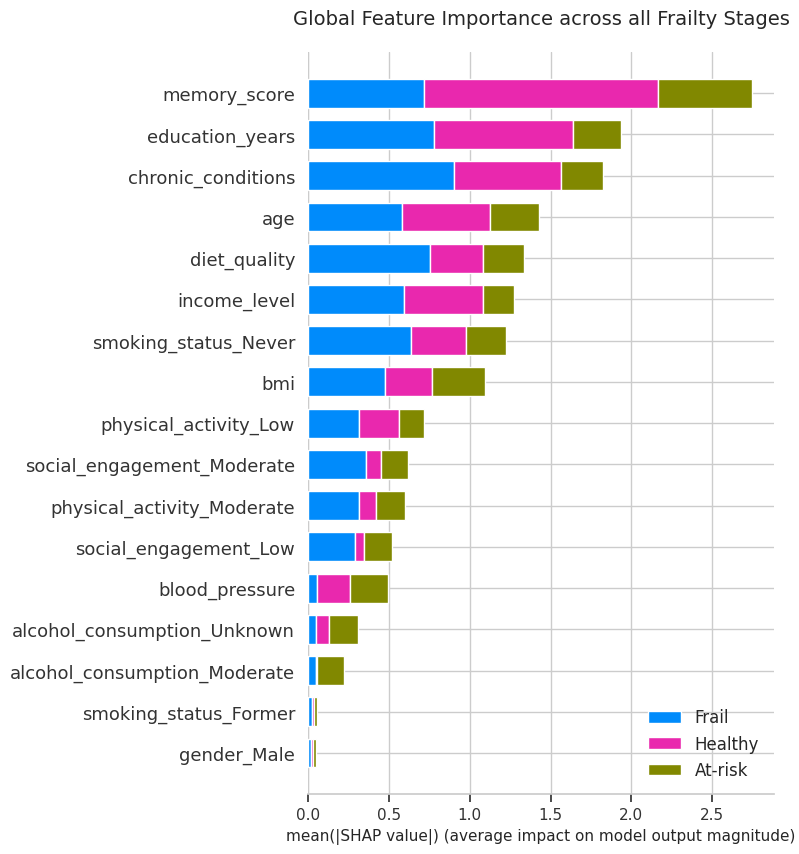

In [23]:
print("--- Generating Global SHAP Summary Plot ---")
plt.figure(figsize=(14,12))

# The summary_plot handles multi-class outputs by stacking the colors for each class
shap.summary_plot(
    shap_values, 
    X_test, 
    plot_type="bar", 
    class_names=['Healthy', 'At-risk', 'Frail'], 
    show=False
)

fig = plt.gcf()
ax = plt.gca()

plt.title(
    "Global Feature Importance across all Frailty Stages",
    fontsize=14,
    pad=20
)
ax.set_xlabel(
    "mean(|SHAP value|) (average impact on model output magnitude)",
    fontsize=11
)
plt.savefig("shap_plot.png", bbox_inches='tight', dpi=300)
plt.show()

## Global Audit Findings: The Socioeconomic Proxy

The Global SHAP Summary plot reveals the internal feature hierarchy of our champion XGBoost model, providing a critical audit of its clinical safety.

**1. Primary Anchor (Clinical Validity):** The model correctly identifies `memory_score` as the single most impactful feature across all diagnostic classes. This validates that the algorithm's foundational logic is rooted in sound physiological metrics rather than arbitrary noise. `chronic_conditions` and `age` also rank highly, further validating the clinical soundness of the model.

**2. The "Dark Logic" Vulnerability:** Crucially, `education_years` emerges as the second most powerful driver of the model's predictions, outweighing vital clinical markers like diet, BMI, and blood pressure. Furthermore, `income_level` ranks as the 6th most important feature. 

This confirms our "Dark Logic" hypothesis: the black-box model is heavily leveraging socioeconomic proxies to calculate frailty risk. In a real-world Hospital-at-Home deployment, utilizing a model that heavily weights a patient's educational background to determine their medical care pathway introduces severe ethical and systemic bias risks.

## Unpacking the 'Frail' Diagnosis

Knowing *what* features are important is not enough; clinicians must understand *how* they affect the most critical diagnosis. To achieve this, we isolate the SHAP values specifically for the **'Frail'** class and generate a Beeswarm plot. 

* **Color** represents the actual patient data value (Red = High value, Blue = Low value).
* **X-Axis position** represents the SHAP value (Impact). Points pushed to the right (+ SHAP) actively increased the model's confidence that the patient is Frail. Points to the left (- SHAP) decreased that risk.


--- Generating SHAP Beeswarm Plot for 'Frail' Classification ---


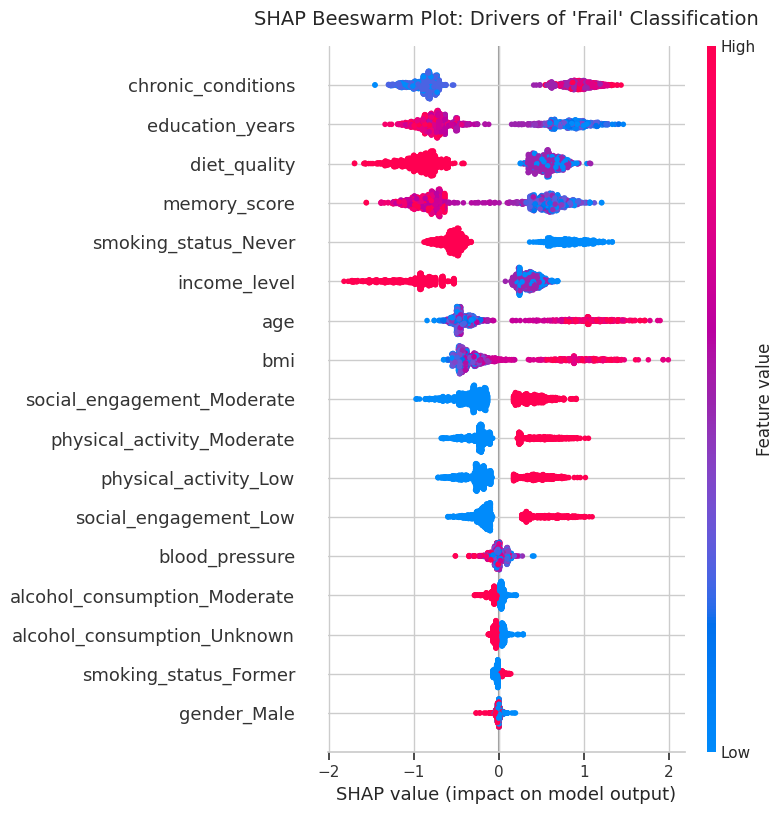

In [24]:
print("\n--- Generating SHAP Beeswarm Plot for 'Frail' Classification ---")
plt.figure(figsize=(12,10))

# Multi-class XGBoost typically returns a list of arrays for each class
if isinstance(shap_values, list):
    frail_shap_values = shap_values[2] 
else:
    frail_shap_values = shap_values[:, :, 2]

# Generate the beeswarm plot for the Frail class
shap.summary_plot(frail_shap_values, X_test, show=False)

plt.title("SHAP Beeswarm Plot: Drivers of 'Frail' Classification", fontsize=14, pad=15)
plt.savefig("shap_plot1.png", bbox_inches='tight', dpi=300)
plt.tight_layout()
plt.show()

## Directional Impact: How the AI Diagnoses Frailty

The SHAP Beeswarm plot allows us to audit the exact directional logic the XGBoost model utilizes when diagnosing a patient as 'Frail' (Class 2). By analyzing the distribution of feature values (Red = High, Blue = Low) against their SHAP values, we can definitively evaluate the model's clinical and ethical safety.

**1. Clinical Validation (Medical Logic)**
The model successfully learned core physiological and clinical fundamentals without being explicitly programmed to do so. 
* **Chronic Conditions:** High values (Red dots) strongly push the prediction to the right (+ SHAP), meaning more chronic conditions directly increase frailty risk.
* **Memory & Diet:** Low values (Blue dots) for `memory_score` and `diet_quality` are clustered on the right, proving the model correctly identifies poor memory and poor nutrition as leading drivers of frailty.
* **Age:** Older patients (Red dots) are consistently pushed to the right, aligning with natural biological aging markers.

**2. The "Dark Logic" Confirmed (Algorithmic Bias)**
The audit exposes a severe ethical vulnerability in the model's handling of socioeconomic variables.
* **Education Years:** Low values (Blue dots) are heavily clustered on the right side of the axis. The algorithm mathematically penalizes patients with less education, automatically increasing their frailty risk score regardless of their physical health.
* **Income Level:** Similarly, low income (Blue dots) strongly drives a 'Frail' diagnosis. 

# Conclusion and Clinical Implementation Strategy

## Summary of Findings
This study investigated the tension between predictive accuracy and algorithmic transparency in triaging elderly patients for Hospital-at-Home pathways. 
1. **The Performance Gap:** Traditional, interpretable White-Box models (Logistic Regression) achieved an 88.45% accuracy but suffered from a 16% False Negative rate for the most vulnerable 'Frail' patients. 
2. **The Algorithmic Champion:** The Black-Box XGBoost model significantly outperformed all other algorithms, achieving a 98.80% overall accuracy, a 0.9996 ROC-AUC, and successfully identifying 98% of all 'Frail' and 'At-risk' patients. Its mathematical stability was validated via 5-Fold Stratified Cross-Validation (+/- 0.2% variance).

## Ethical Implications of Algorithmic Bias
Despite its superior predictive power, deploying the XGBoost model "as-is" presents severe ethical risks. The SHAP Explainable AI audit revealed that while the model correctly anchored its logic in physiological markers (e.g., `memory_score`, `chronic_conditions`), it also heavily weighted socioeconomic proxies. 

Specifically, `education_years` emerged as the second most impactful feature driving the model's predictions. The algorithm mathematically penalized patients with fewer years of education, automatically increasing their frailty risk score. In a clinical setting, utilizing this model without human oversight would automate and scale systemic biases, potentially triaging medical care based on socioeconomic status rather than physiological need.

# Future Work & Recommendations
To safely implement highly accurate ensemble models in clinical pathways, we recommend the following next steps:
* **Model Fairness Interventions:** Retrain the XGBoost algorithm using algorithmic fairness techniques (such as re-weighting or adversarial debiasing) to strictly reduce the model's reliance on `education_years` and `income_level` without sacrificing overall accuracy.
* **Human-in-the-Loop (HITL) Deployment:** Rather than functioning as an autonomous decision-maker, the XGBoost model should be deployed alongside real-time SHAP dashboards. This ensures that attending clinicians receive the model's highly accurate risk prediction *alongside* an explanation of how it was calculated, allowing them to override the AI if the decision was driven heavily by socioeconomic bias.
 

**End of Notebook.**